# CS690R: Bio-PM IRB Embedding Extraction

**Pipeline division:**
- **Scripts** (`run_extraction_pipeline.sh`): preprocessing, feature extraction, embedding verification
- **This notebook**: dataset inspection, debug diagnostics, even/odd split, UMAP visualization, LOSO logistic regression

**Run scripts first:**
```bash
conda activate biopm-690r
export BIOPM_ROOT=/Users/vpk11/Desktop/690r/Downloads/CS690TR
bash run_extraction_pipeline.sh
```
Then use this notebook for exploration and analysis.

**Embedding layout (1028-d):**
```
[0:64]     mean-pool transformer tokens   (movement element structure)
[64:128]   std-pool transformer tokens    (movement element variability) -- may be near-zero
[128:1028] gravity flattened 300x3        (posture/orientation)          -- always meaningful
```

In [1]:
# ============================================================
# PATHS -- repo-relative configuration
# ============================================================
import os
REPO_ROOT        = os.path.abspath(".")
BIOPM_ROOT       = os.path.join(REPO_ROOT, "CS690TR")
DATA_DIR         = "data"                         # clinical_scores.npz + windows.npz
PREPROCESSED_DIR = "preprocessed"                # written by irb_preprocess.py (script)
FEATURES_PATH    = "features/biopm_features.npz" # written by irb_extract.py (script)
RESULTS_DIR      = "results"
FIGURES_DIR      = "results/figures"             # UMAP plot saved here
SPLITS_DIR       = "results/splits"              # even/odd split indices
LR_RESULTS_PATH  = "results/lr_loso_results.txt"

# Debug settings (Section 2)
DEBUG_SUBJECT   = 549
DEBUG_N_WINDOWS = 20


In [ ]:
%matplotlib inline
import os
import sys
import warnings
from collections import defaultdict, Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import pandas
import sklearn
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import umap
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)

if not os.path.isdir(BIOPM_ROOT):
    raise RuntimeError(
        f"BIOPM_ROOT not found: {BIOPM_ROOT!r}\n"
        "Update BIOPM_ROOT in the config cell above."
    )
if BIOPM_ROOT not in sys.path:
    sys.path.insert(0, BIOPM_ROOT)

from src.data.preprocessing import bandpass_filter, lowpass_filter, detect_zero_crossings
from src.models.biopm import BioPMModel, masked_mean_std

CHECKPOINT = os.path.join(BIOPM_ROOT, "checkpoints", "checkpoint.pt")

print(f"torch  : {torch.__version__}")
print(f"numpy  : {np.__version__}")
print(f"scipy  : {scipy.__version__}")
print(f"pandas : {pandas.__version__}")
print(f"sklearn: {sklearn.__version__}")
print(f"checkpoint : {'OK' if os.path.isfile(CHECKPOINT) else 'NOT FOUND -- check BIOPM_ROOT'}")
print("All imports OK")

## 1. Inspect Dataset

Characterize `clinical_scores.npz` and `windows.npz`. Run once to understand structure before processing.

In [ ]:
def _hr(label="", w=60):
    if label:
        pad = (w - len(label) - 2) // 2
        print("=" * pad + f" {label} " + "=" * (w - pad - len(label) - 2))
    else:
        print("=" * w)

# ---- clinical_scores ----
_hr("clinical_scores.npz")
raw  = np.load(f"{DATA_DIR}/clinical_scores.npz", allow_pickle=True)
clin = raw["clinical_scores"].item()
keys = list(clin.keys())

subjects = sorted(set(k[0] for k in keys))
weeks    = sorted(set(k[1] for k in keys))
arats    = np.array([clin[k].ARAT for k in keys])
fmas     = np.array([clin[k].FMA  for k in keys])
healthy  = {k[0] for k in keys if clin[k].ARAT == 57 and clin[k].FMA == 66}
stroke   = {k[0] for k in keys} - healthy

print(f"Total (subj, week) entries : {len(keys)}")
print(f"Unique subjects            : {len(subjects)}  {subjects[:10]}...")
print(f"Weeks                      : {weeks}")
print(f"ARAT range                 : [{arats.min():.0f}, {arats.max():.0f}]")
print(f"FMA  range                 : [{fmas.min():.0f}, {fmas.max():.0f}]")
print(f"Healthy subjects (max score): {len(healthy)}  {sorted(healthy)}")
print(f"Stroke  subjects            : {len(stroke)}   (sample: {sorted(stroke)[:5]}...)")

# ---- windows ----
_hr("windows.npz")
print("Loading windows.npz (may take 1-2 min) ...", flush=True)
raw_wins = np.load(f"{DATA_DIR}/windows.npz", allow_pickle=True)
windows  = raw_wins["windows"]
w0       = windows[0]

print(f"Total windows     : {len(windows)}")
print(f"window attributes : {list(vars(w0).keys())}")
print(f"wnd.acc shape     : {w0.acc.shape}  (T=90 samples, 3 axes)")
print(f"wnd.sample_rate   : {w0.sample_rate} Hz")
win_sec = w0.acc.shape[0] / w0.sample_rate
print(f"Window duration   : {win_sec:.1f} seconds")

win_subs = sorted(set(w.subject for w in windows))
win_wks  = sorted(set(w.week for w in windows))
print(f"Subjects in windows: {len(win_subs)}  {win_subs[:10]}...")
print(f"Weeks in windows   : {win_wks}")

counts = Counter((w.subject, w.week) for w in windows)
vals   = list(counts.values())
print(f"Windows per (subj,week): min={min(vals)}  max={max(vals)}  median={np.median(vals):.0f}")

acc_sample = np.stack([w.acc for w in windows[:100]])
print(f"\nAcc value range (first 100 windows):")
print(f"  min={acc_sample.min():.4f}  max={acc_sample.max():.4f}  mean={acc_sample.mean():.4f}")

# Cross-reference
_hr("Cross-reference")
clin_pairs = set(keys)
win_pairs  = set((w.subject, w.week) for w in windows)
both       = clin_pairs & win_pairs
only_clin  = clin_pairs - win_pairs
only_win   = win_pairs - clin_pairs
print(f"(subj,week) pairs in both      : {len(both)}")
print(f"In clinical only (no windows)  : {len(only_clin)}")
print(f"In windows only  (no clinical) : {len(only_win)}")

_hr("Bio-PM config")
print(f"  WS        = {win_sec:.0f}   (window size in seconds)")
print(f"  target_FS = {w0.sample_rate}  (already correct rate, no resampling)")
print(f"  pad_size  = {int(win_sec * 192 / 10)}   (int({win_sec:.0f} * 192 / 10))")
_hr()

=================== clinical_scores.npz ====================
Total (subj, week) entries : 223
Unique subjects            : 61  [500, 502, 503, 506, 507, 509, 510, 512, 515, 516]...
Weeks                      : [2, 4, 6, 8, 12, 16, 20, 24]
ARAT range                 : [0, 57]
FMA  range                 : [3, 66]
Healthy subjects (max score): 8  [509, 517, 526, 529, 532, 533, 539, 551]
Stroke  subjects            : 53   (sample: [500, 502, 503, 506, 507]...)
======================= windows.npz ========================
Loading windows.npz (may take 1-2 min) ...
Total windows     : 587046
window attributes : ['subject', 'week', 'start_idx', 'sample_rate', 'acc', 'vel', 'pos', 'jerk']
wnd.acc shape     : (90, 3)  (T=90 samples, 3 axes)
wnd.sample_rate   : 30 Hz
Window duration   : 3.0 seconds
Subjects in windows: 36  [507, 518, 532, 533, 535, 537, 539, 541, 542, 543]...
Weeks in windows   : [2, 4, 6, 8, 12, 16, 20, 24]
Windows per (subj,week): min=55  max=12617  median=2119

Acc value range

## 2. Debug Pipeline

Step-by-step diagnostic on a single subject. Run **before** preprocessing to check how many movement elements (MEs) Bio-PM detects per window.

**Interpretation:**
- Mean MEs/window < 3: transformer stream `[0:128]` will be near-zero. Use gravity `[128:1028]` only.
- Mean MEs/window 3-10: low count, std-pool `[64:128]` may be unreliable.
- Mean MEs/window > 10: transformer stream should work.

In [ ]:
# Helper functions for debug section
def hr(label="", w=64):
    if label:
        pad = (w - len(label) - 2) // 2
        print("=" * pad + f" {label} " + "=" * (w - pad - len(label) - 2))
    else:
        print("=" * w)

def check_array(name, arr, indent=4):
    sp = " " * indent
    if arr is None:
        print(f"{sp}{name}: None")
        return
    flat   = arr.flatten()
    n_nan  = int(np.isnan(flat).sum())
    n_inf  = int(np.isinf(flat).sum())
    finite = flat[np.isfinite(flat)]
    if len(finite) > 0:
        print(f"{sp}{name}: shape={arr.shape}  dtype={arr.dtype}")
        print(f"{sp}  range=[{finite.min():.4f}, {finite.max():.4f}]  mean={finite.mean():.4f}  std={finite.std():.4f}")
        print(f"{sp}  NaN={n_nan}/{len(flat)}  Inf={n_inf}")
        if n_nan == len(flat):
            print(f"{sp}  *** ALL NaN -- zero/garbage embeddings ***")
        elif n_nan > len(flat) * 0.9:
            print(f"{sp}  *** >90% NaN -- very sparse, embeddings unreliable ***")
    else:
        print(f"{sp}{name}: ALL NaN or Inf -- {arr.shape}")

In [ ]:
DEBUG_CONFIG = {
    "HighF1": 12, "LowF1": 0.5, "Order1": 6,
    "target_FS": 30, "WS": 3, "pad_size": 57,
    "normalize_size_target": 32, "normalize_size_assign": 32,
}

# Stage 1: Load
hr("Stage 1: Load data")
_clin = np.load(f"{DATA_DIR}/clinical_scores.npz", allow_pickle=True)["clinical_scores"].item()
_wins_all = np.load(f"{DATA_DIR}/windows.npz", allow_pickle=True)["windows"]
dbg_windows = [w for w in _wins_all if w.subject == DEBUG_SUBJECT]
if not dbg_windows:
    raise RuntimeError(f"Subject {DEBUG_SUBJECT} not found. Set DEBUG_SUBJECT to a valid ID.")
dbg_test = dbg_windows[:DEBUG_N_WINDOWS]
clin_key = (DEBUG_SUBJECT, dbg_test[0].week)
if clin_key in _clin:
    arat = _clin[clin_key].ARAT
    fma  = _clin[clin_key].FMA
    print(f"Subject {DEBUG_SUBJECT}: ARAT={arat:.0f}  FMA={fma:.0f}  "
          f"({'healthy' if arat==57 and fma==66 else 'stroke'})")
print(f"Testing {len(dbg_test)} windows")

# Stage 2: Raw acceleration
hr("Stage 2: Raw acceleration")
w0 = dbg_test[0]
print(f"wnd.acc shape: {w0.acc.shape}  sample_rate: {w0.sample_rate}")
check_array("wnd.acc", w0.acc)

# Stage 3: Bandpass filter
hr("Stage 3: Bandpass filter (0.5-12 Hz)")
try:
    acc_filt = bandpass_filter(w0.acc, DEBUG_CONFIG["LowF1"], DEBUG_CONFIG["HighF1"],
                               DEBUG_CONFIG["target_FS"], order=DEBUG_CONFIG["Order1"])
    check_array("acc_filt", acc_filt)
except Exception as e:
    raise RuntimeError(f"Bandpass failed: {e}")

signal_power = np.mean(acc_filt ** 2)
print(f"  Signal power after bandpass: {signal_power:.6f}")
if signal_power < 1e-6:
    print("  *** NEAR-ZERO POWER -- dataset LP filter may have removed frequencies Bio-PM needs ***")

# Stage 4: ME detection across all test windows
hr("Stage 4: Zero-crossing ME detection")
me_counts  = []
fail_count = 0
for wnd in dbg_test:
    t_w = np.arange(wnd.acc.shape[0]) / DEBUG_CONFIG["target_FS"]
    try:
        acc_f = bandpass_filter(wnd.acc, DEBUG_CONFIG["LowF1"], DEBUG_CONFIG["HighF1"],
                                DEBUG_CONFIG["target_FS"], order=DEBUG_CONFIG["Order1"])
        (_, _, me_list, _, _, _, _, _, _, _) = detect_zero_crossings(acc_f, t_w, DEBUG_CONFIG)
        me_counts.append(len(me_list))
    except Exception:
        fail_count += 1
        me_counts.append(0)

me_counts = np.array(me_counts)
print(f"Windows tested : {len(me_counts)}")
print(f"Failures       : {fail_count}")
print(f"MEs per window : min={me_counts.min()}  max={me_counts.max()}  "
      f"mean={me_counts.mean():.1f}  median={np.median(me_counts):.1f}")
print(f"Windows with 0 MEs: {(me_counts == 0).sum()}/{len(me_counts)} "
      f"({100*(me_counts==0).mean():.1f}%)")

if me_counts.mean() < 3:
    print("\n*** WARNING: Very few MEs. Bio-PM transformer [0:128] will be near-zero.")
    print("    Use gravity-only features [128:1028] for downstream analysis.")
elif me_counts.mean() < 10:
    print("\n  NOTE: Low ME count. Std-pool [64:128] may be near-zero.")
else:
    print("\n  ME count looks healthy. Transformer stream should work.")

====================== Stage 1: Load data ======================
Subject 549: ARAT=2  FMA=11  (stroke)
Testing 20 windows
================== Stage 2: Raw acceleration ===================
wnd.acc shape: (90, 3)  sample_rate: 30
    wnd.acc: shape=(90, 3)  dtype=float64
      range=[-0.5486, 1.4764]  mean=0.0363  std=0.3438
      NaN=0/270  Inf=0
============= Stage 3: Bandpass filter (0.5-12 Hz) =============
    acc_filt: shape=(90, 3)  dtype=float64
      range=[-0.6013, 0.5204]  mean=-0.0027  std=0.1734
      NaN=0/270  Inf=0
  Signal power after bandpass: 0.030076
============= Stage 4: Zero-crossing ME detection ==============
Windows tested : 20
Failures       : 0
MEs per window : min=10  max=29  mean=18.6  median=18.0
Windows with 0 MEs: 0/20 (0.0%)

  ME count looks healthy. Transformer stream should work.


In [ ]:
# Stage 5: Inspect one ME extraction in detail
hr("Stage 5: ME detail (window 0)")
t_w   = np.arange(dbg_test[0].acc.shape[0]) / DEBUG_CONFIG["target_FS"]
acc_f = bandpass_filter(dbg_test[0].acc, DEBUG_CONFIG["LowF1"], DEBUG_CONFIG["HighF1"],
                        DEBUG_CONFIG["target_FS"], order=DEBUG_CONFIG["Order1"])
(_, _, me_list, me_norm, me_info, _, _, pos_info, zc_list, _) = \
    detect_zero_crossings(acc_f, t_w, DEBUG_CONFIG)

n_me = len(me_list)
print(f"MEs found in window 0: {n_me}")
if n_me > 0:
    check_array("me_norm (ME patches)", me_norm)
    print(f"  me_info columns: {list(me_info.columns)}")
    print(f"  me_info sample:\n{me_info.head(3).to_string()}")
    check_array("pos_info", np.array(pos_info))
else:
    print("  No MEs found -- entire x_acc_filt will be NaN-padded for this window.")

# Stage 6: Gravity stream
hr("Stage 6: Gravity stream")
acc_grav = lowpass_filter(dbg_test[0].acc, DEBUG_CONFIG["LowF1"],
                          DEBUG_CONFIG["target_FS"], order=DEBUG_CONFIG["Order1"])
check_array("gravity signal", acc_grav)

# Stage 7: Build x_acc_filt
hr("Stage 7: x_acc_filt (what gets written to HDF5)")
PAD = DEBUG_CONFIG["pad_size"]
if n_me > 0:
    x_acc = np.concatenate([
        me_norm,
        np.array(pos_info).reshape(-1, 1),
        me_info[["axis", "len", "min", "max", "dirct"]].values,
    ], axis=1)
    pad = np.full((PAD - n_me, x_acc.shape[1]), np.nan)
    x_acc_padded = np.vstack([x_acc, pad]) if n_me < PAD else x_acc[:PAD]
    check_array("x_acc_filt (padded)", x_acc_padded)
    n_nan_rows   = np.isnan(x_acc_padded).all(axis=1).sum()
    n_valid_rows = PAD - n_nan_rows
    print(f"  Valid token rows : {n_valid_rows}/{PAD}")
    print(f"  NaN-padded rows  : {n_nan_rows}/{PAD}")
    if n_nan_rows == PAD:
        print("  *** ALL ROWS NaN -- this window produces no signal to Bio-PM ***")
else:
    x_acc_padded = None
    print("  x_acc_filt: all NaN (no MEs detected)")
    print("  *** THIS IS THE ZERO-EMBEDDING BUG -- no valid tokens to encode ***")

# Stage 8: Checkpoint test
hr("Stage 8: Checkpoint")
if os.path.isfile(CHECKPOINT):
    ckpt   = torch.load(CHECKPOINT, map_location="cpu", weights_only=False)
    model  = BioPMModel(n_classes=2)
    result = model.encoder_acc.load_state_dict(ckpt, strict=False)
    print(f"Missing keys   : {len(result.missing_keys)}")
    print(f"Unexpected keys: {len(result.unexpected_keys)}")
    if len(result.missing_keys) > 5:
        print("  *** MANY MISSING KEYS -- model may run with random weights ***")
    else:
        print("  Checkpoint loaded OK.")
    if n_me > 0 and x_acc_padded is not None:
        model.eval()
        with torch.no_grad():
            patches = torch.from_numpy(x_acc_padded[:, :32]).float().unsqueeze(0)
            pos_t   = torch.from_numpy(x_acc_padded[:, 32]).float().unsqueeze(0)
            add_t   = torch.from_numpy(x_acc_padded[:, 33:]).float().unsqueeze(0)
            mask_t  = torch.zeros(1, PAD)
            tokens = model.encoder_acc(patches, pos_t, mask_t, add_t)
            pooled = masked_mean_std(tokens)
        check_array("pooled (B,128)", pooled.numpy())
        n_zero = (pooled.abs() < 1e-6).sum().item()
        print(f"  Near-zero values in pooled: {n_zero}/128")
        if n_zero > 100:
            print("  *** POOLED NEARLY ALL ZERO -- zero-embedding bug confirmed ***")
        else:
            print("  Pooled looks non-zero. Model is working.")
else:
    print(f"Checkpoint not found at {CHECKPOINT}")

# Summary
hr("Summary")
avg_me = me_counts.mean()
pct_zero_me = 100 * (me_counts == 0).mean()
print(f"Mean MEs per window : {avg_me:.1f}")
print(f"% windows with 0 MEs: {pct_zero_me:.1f}%")
if avg_me < 2:
    print("\nDIAGNOSIS: Zero-embedding bug. Use gravity-only: features[:, 128:]")
elif avg_me < 5:
    print("\nDIAGNOSIS: Low ME count. Gravity [128:1028] is the reliable part.")
else:
    print("\nDIAGNOSIS: ME count OK.")
hr()

================ Stage 5: ME detail (window 0) =================
MEs found in window 0: 10
    me_norm (ME patches): shape=(10, 32)  dtype=float64
      range=[-0.3691, 0.5270]  mean=0.0295  std=0.2059
      NaN=0/320  Inf=0
  me_info columns: ['axis', 'start_point', 'end_point', 'len', 'min', 'max', 'dirct', 'peaks']
  me_info sample:
   axis  start_point  end_point  len           min       max  dirct  peaks
0     0           17         47   32 -1.235633e-17  0.089638      1      1
0     0           47         69   24  1.235633e-17  0.297741     -1      1
0     0           69         80   13 -4.220772e-13  0.522008      1      1
    pos_info: shape=(10,)  dtype=float64
      range=[0.3556, 0.9056]  mean=0.6572  std=0.1952
      NaN=0/10  Inf=0
=================== Stage 6: Gravity stream ====================
    gravity signal: shape=(90, 3)  dtype=float64
      range=[-0.3290, 0.3915]  mean=0.0114  std=0.1550
      NaN=0/270  Inf=0
======= Stage 7: x_acc_filt (what gets written to HDF

## 3. Script Verification

Run `bash run_extraction_pipeline.sh` before this section. The script handles:
1. **Preprocess**: groups windows by `(subject, week)`, extracts movement element tokens, writes one HDF5 per visit to `preprocessed/`
2. **Extract**: runs Bio-PM encoder on all HDF5 files, saves `features/biopm_features.npz`
3. **Verify**: `verify_embeddings.py` checks shape, NaN/Inf, and embedding quality

This cell just confirms the scripts ran and outputs are valid before analysis.

In [ ]:
print("=" * 56)
print("Script Output Verification")
print("=" * 56)

# 1. Preprocessed HDF5 files (one per visit = one per (subject, week))
h5_files = sorted(
    f for f in os.listdir(PREPROCESSED_DIR) if f.endswith(".h5")
) if os.path.isdir(PREPROCESSED_DIR) else []

print(f"\nPreprocessed HDF5 files : {len(h5_files)}")
if len(h5_files) == 0:
    print("  FAIL: no files found. Run: bash run_extraction_pipeline.sh")
elif len(h5_files) != 198:
    print(f"  WARNING: expected 198 (one per subject-week visit), got {len(h5_files)}")
else:
    print("  OK: 198 files -- one per subject-week visit")

# 2. Features file
if not os.path.isfile(FEATURES_PATH):
    print(f"\nFAIL: {FEATURES_PATH} not found. Run: bash run_extraction_pipeline.sh")
else:
    d = np.load(FEATURES_PATH, allow_pickle=True)
    X    = d["features"]
    y    = d["labels"].astype(int)
    subj = d["subj"].astype(int)
    week = d["week"].astype(int)

    n_nan    = int(np.isnan(X).sum())
    n_inf    = int(np.isinf(X).sum())
    n_zero   = int((np.abs(X) < 1e-6).all(axis=1).sum())
    xfm_abs  = float(np.abs(X[:, :128]).mean())
    grav_abs = float(np.abs(X[:, 128:]).mean())
    visits   = set(zip(subj.tolist(), week.tolist()))

    print(f"\nFeatures: {FEATURES_PATH}")
    print(f"  Shape        : {X.shape}  (N, 1028)")
    print(f"  NaN / Inf    : {n_nan} / {n_inf}  (expected 0 / 0)")
    print(f"  All-zero rows: {n_zero}  (expected 0)")
    print(f"  Windows      : {len(X)}")
    print(f"  Visits       : {len(visits)}  (unique subject-week pairs)")
    print(f"  Healthy      : {int((y == 1).sum())} windows")
    print(f"  Stroke       : {int((y == 0).sum())} windows")
    print(f"\n  Transformer [0:128]  mean_abs = {xfm_abs:.4f}")
    print(f"  Gravity     [128:]   mean_abs = {grav_abs:.4f}")

    ok = (X.shape[1] == 1028 and n_nan == 0 and n_inf == 0
          and n_zero == 0 and xfm_abs > 0.01)
    print(f"\n  Status: {'OK -- ready for analysis' if ok else 'FAIL -- check output above'}")

Script Output Verification

Preprocessed HDF5 files : 198
  OK: 198 files -- one per subject-week visit

Features: features/biopm_features.npz
  Shape        : (587046, 1028)  (N, 1028)
  NaN / Inf    : 0 / 0  (expected 0 / 0)
  All-zero rows: 0  (expected 0)
  Windows      : 587046
  Visits       : 198  (unique subject-week pairs)
  Healthy      : 28389 windows
  Stroke       : 558657 windows

  Transformer [0:128]  mean_abs = 0.5638
  Gravity     [128:]   mean_abs = 0.0552

  Status: OK -- ready for analysis


## 4. Analysis

Three tasks on **visit-level** features (windows mean-pooled per `(subject, week)`):

1. **Even/odd window split** -- within each visit, even-position windows go to train, odd to test
2. **UMAP visualization** -- 198 visit-level 1028-d features, colored healthy vs stroke
3. **LOSO logistic regression** -- leave-one-subject-out on visit-level features, reports AUC

**Visit structure:** 587k windows -> 198 visits (4 healthy, 194 stroke). Each visit is one `(subject, week)` clinical assessment. `class_weight='balanced'` handles the 4:194 imbalance.

In [ ]:
def load_features(path):
    d = np.load(path, allow_pickle=True)
    return (d["features"],
            d["labels"].astype(int),
            d["subj"].astype(int),
            d["week"].astype(int),
            d["ARAT"].astype(float),
            d["FMA"].astype(float))


def even_odd_split(subj_arr, week_arr):
    """Within each (subj, week) group, even positions -> train, odd -> test."""
    groups     = defaultdict(list)
    for i, (s, w) in enumerate(zip(subj_arr, week_arr)):
        groups[(s, w)].append(i)

    within_idx = np.zeros(len(subj_arr), dtype=np.int64)
    for indices in groups.values():
        for pos, global_i in enumerate(indices):
            within_idx[global_i] = pos

    train_mask = (within_idx % 2) == 0
    test_mask  = (within_idx % 2) == 1
    return train_mask, test_mask


def aggregate_visits(features, labels, subj_arr, week_arr, arat_arr, fma_arr):
    """Mean-pool windows within each (subj, week) to one visit-level vector."""
    groups = defaultdict(list)
    for i, (s, w) in enumerate(zip(subj_arr, week_arr)):
        groups[(s, w)].append(i)

    vf, vl, vs, vw, va, vfma = [], [], [], [], [], []
    for (s, w), indices in sorted(groups.items()):
        idx = np.array(indices)
        vf.append(features[idx].mean(axis=0))
        vl.append(int(labels[idx[0]]))
        vs.append(int(s))
        vw.append(int(w))
        va.append(float(arat_arr[idx[0]]))
        vfma.append(float(fma_arr[idx[0]]))

    return (np.array(vf), np.array(vl), np.array(vs),
            np.array(vw), np.array(va), np.array(vfma))

In [ ]:
def loso_lr(visit_features, visit_labels, visit_subj, results_path):
    """Leave-one-subject-out LR on visit-level features. Returns (overall_auc, all_probs)."""
    unique_subjects = np.unique(visit_subj)
    all_probs       = np.zeros(len(visit_labels), dtype=float)
    per_subj_aucs   = []

    for subj in tqdm(unique_subjects, desc="LOSO LR", unit="subj"):
        test_mask  = visit_subj == subj
        train_mask = ~test_mask

        X_tr, y_tr = visit_features[train_mask], visit_labels[train_mask]
        X_te, y_te = visit_features[test_mask],  visit_labels[test_mask]

        if len(np.unique(y_tr)) < 2:
            tqdm.write(f"  s{subj}: skip -- training set has only one class")
            continue

        scaler  = StandardScaler()
        X_tr_s  = scaler.fit_transform(X_tr)
        X_te_s  = scaler.transform(X_te)

        lr = LogisticRegression(max_iter=2000, class_weight="balanced",
                                C=1.0, solver="lbfgs")
        lr.fit(X_tr_s, y_tr)
        probs = lr.predict_proba(X_te_s)[:, 1]
        all_probs[test_mask] = probs

        if len(np.unique(y_te)) > 1:
            auc = roc_auc_score(y_te, probs)
            per_subj_aucs.append((subj, auc, int(y_te.sum())))

    overall_auc = roc_auc_score(visit_labels, all_probs)

    lines = [
        "=" * 56,
        "LOSO Logistic Regression Results (visit-level)",
        "=" * 56,
        f"Total visits   : {len(visit_labels)}",
        f"Healthy visits : {int(visit_labels.sum())}",
        f"Stroke visits  : {int((visit_labels == 0).sum())}",
        "",
        "Subjects with mixed labels (AUC computable):",
    ]
    for s, a, n in per_subj_aucs:
        lines.append(f"  Subject {s:3d}: AUC={a:.3f}  healthy_visits={n}")
    lines += [
        "",
        f"Overall LOSO AUC : {overall_auc:.4f}",
        f"Threshold check  : {'PASS (>0.6)' if overall_auc > 0.6 else 'FAIL (<0.6) -- investigate labels'}",
        "=" * 56,
    ]
    report = "\n".join(lines)
    print(report)

    os.makedirs(os.path.dirname(results_path) or ".", exist_ok=True)
    with open(results_path, "w") as f:
        f.write(report + "\n")

    return overall_auc, all_probs


def run_umap(visit_features, visit_labels, out_path):
    """2D UMAP of visit-level features, colored healthy vs stroke."""
    print(f"Computing UMAP on {len(visit_features)} visits ...")

    scaler = StandardScaler()
    X_s    = scaler.fit_transform(visit_features)

    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        random_state=42, verbose=False)
    emb = reducer.fit_transform(X_s)

    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    palette       = {0: "#E05C5C", 1: "#4CAF50"}
    legend_labels = {
        0: f"Stroke  (n={int((visit_labels == 0).sum())})",
        1: f"Healthy (n={int((visit_labels == 1).sum())})",
    }

    fig, ax = plt.subplots(figsize=(8, 6))
    for lbl in [0, 1]:
        mask = visit_labels == lbl
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=palette[lbl], label=legend_labels[lbl],
                   s=70, alpha=0.85, edgecolors="white", linewidths=0.4)

    ax.set_title("UMAP: Bio-PM Embeddings (visit-level)\nHealthy vs Stroke", fontsize=13)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(frameon=True, fontsize=10)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()

    return emb

Bio-PM IRB Analysis
  Windows : 587046
  Healthy : 28389 windows
  Stroke  : 558657 windows

[1/3] Even/odd window split ...
  Train windows : 293577
  Test  windows : 293469
  Train healthy : 14196
  Test  healthy : 14193
  Saved: results/splits/split_indices.npz

Aggregating to visit level ...
  Total visits   : 198
  Healthy visits : 4
  Stroke  visits : 194

[2/3] UMAP visualization ...
Computing UMAP on 198 visits ...


/opt/anaconda3/envs/biopm-690r/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
python(5972) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Saved: results/figures/umap_healthy_vs_impaired.png


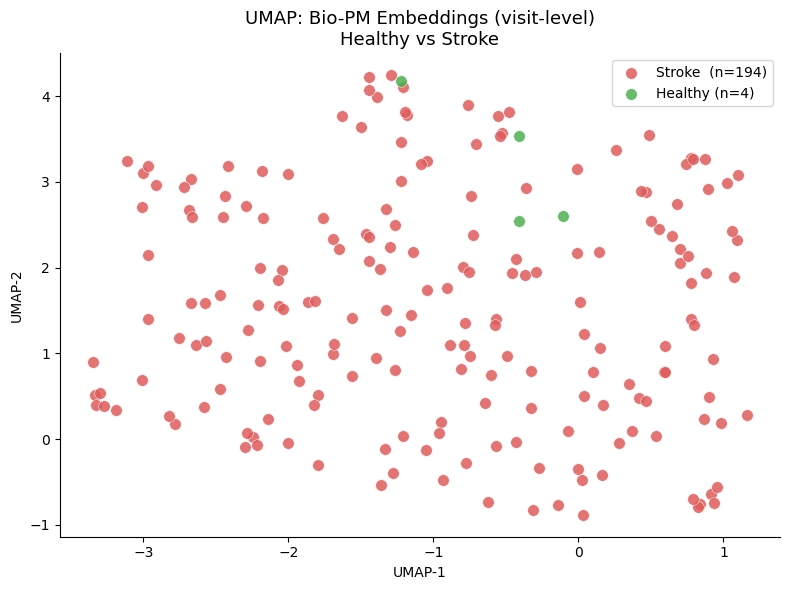


[3/3] LOSO logistic regression ...


LOSO LR:   0%|          | 0/36 [00:00<?, ?subj/s]

LOSO Logistic Regression Results (visit-level)
Total visits   : 198
Healthy visits : 4
Stroke visits  : 194

Subjects with mixed labels (AUC computable):
  Subject 532: AUC=1.000  healthy_visits=1
  Subject 533: AUC=0.857  healthy_visits=1
  Subject 539: AUC=0.286  healthy_visits=1
  Subject 551: AUC=0.833  healthy_visits=1

Overall LOSO AUC : 0.7925
Threshold check  : PASS (>0.6)

LOSO AUC : 0.7925  PASS
Outputs  : results/


In [ ]:
print("=" * 56)
print("Bio-PM IRB Analysis")
print("=" * 56)

an_features, an_labels, an_subj, an_week, an_arat, an_fma = load_features(FEATURES_PATH)
N = len(an_labels)
print(f"  Windows : {N}")
print(f"  Healthy : {an_labels.sum()} windows")
print(f"  Stroke  : {(an_labels == 0).sum()} windows")

# 1. Even/odd split
print("\n[1/3] Even/odd window split ...")
train_mask, test_mask = even_odd_split(an_subj, an_week)
os.makedirs(SPLITS_DIR, exist_ok=True)
split_path = os.path.join(SPLITS_DIR, "split_indices.npz")
np.savez(split_path, train_mask=train_mask, test_mask=test_mask)
print(f"  Train windows : {train_mask.sum()}")
print(f"  Test  windows : {test_mask.sum()}")
print(f"  Train healthy : {an_labels[train_mask].sum()}")
print(f"  Test  healthy : {an_labels[test_mask].sum()}")
print(f"  Saved: {split_path}")

# Visit-level aggregation
print("\nAggregating to visit level ...")
vf, vl, vs, vw, va, vfma = aggregate_visits(
    an_features, an_labels, an_subj, an_week, an_arat, an_fma
)
n_healthy = int(vl.sum())
n_stroke  = int((vl == 0).sum())
print(f"  Total visits   : {len(vl)}")
print(f"  Healthy visits : {n_healthy}")
print(f"  Stroke  visits : {n_stroke}")

# 2. UMAP
print("\n[2/3] UMAP visualization ...")
umap_path = os.path.join(FIGURES_DIR, "umap_healthy_vs_impaired.png")
emb = run_umap(vf, vl, umap_path)

# 3. LOSO LR
print("\n[3/3] LOSO logistic regression ...")
overall_auc, _ = loso_lr(vf, vl, vs, LR_RESULTS_PATH)

print("\n" + "=" * 56)
print(f"LOSO AUC : {overall_auc:.4f}  {'PASS' if overall_auc > 0.6 else 'FAIL -- investigate'}")
print(f"Outputs  : {RESULTS_DIR}/")
print("=" * 56)

In [ ]:
# ============================================================
# Analysis on pre-exported legacy schema (lightweight notebook path)
# ============================================================
LEGACY_FEATURES_PATH = "features/biopm_features_legacy_schema.npz"

if not os.path.isfile(LEGACY_FEATURES_PATH):
    raise FileNotFoundError(
        f"{LEGACY_FEATURES_PATH} not found.\n"
        "Run: bash 'extraction pipeline/run_extraction_pipeline.sh'\n"
        "(step 4 exports the legacy-schema file)."
    )


def loso_lr_with_f1(visit_features, visit_labels, visit_subj, results_path):
    from sklearn.metrics import f1_score

    unique_subjects = np.unique(visit_subj)
    all_probs = np.zeros(len(visit_labels), dtype=float)
    per_subj_aucs = []
    fold_f1s = []

    for subj in tqdm(unique_subjects, desc="LOSO LR", unit="subj"):
        test_mask = visit_subj == subj
        train_mask = ~test_mask

        X_tr, y_tr = visit_features[train_mask], visit_labels[train_mask]
        X_te, y_te = visit_features[test_mask], visit_labels[test_mask]

        if len(np.unique(y_tr)) < 2:
            tqdm.write(f"  s{subj}: skip -- training set has only one class")
            continue

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        lr = LogisticRegression(max_iter=2000, class_weight="balanced", C=1.0, solver="lbfgs")
        lr.fit(X_tr_s, y_tr)

        probs = lr.predict_proba(X_te_s)[:, 1]
        preds = (probs >= 0.5).astype(int)
        all_probs[test_mask] = probs

        fold_f1s.append(f1_score(y_te, preds, average="macro", zero_division=0))

        if len(np.unique(y_te)) > 1:
            auc = roc_auc_score(y_te, probs)
            per_subj_aucs.append((subj, auc, int(y_te.sum())))

    overall_auc = roc_auc_score(visit_labels, all_probs)
    overall_f1 = float(np.mean(fold_f1s)) if fold_f1s else float("nan")

    lines = [
        "=" * 56,
        "LOSO Logistic Regression Results (visit-level)",
        "=" * 56,
        f"Total visits   : {len(visit_labels)}",
        f"Healthy visits : {int(visit_labels.sum())}",
        f"Stroke visits  : {int((visit_labels == 0).sum())}",
        "",
        "Subjects with mixed labels (AUC computable):",
    ]
    for s, a, n in per_subj_aucs:
        lines.append(f"  Subject {s:3d}: AUC={a:.3f}  healthy_visits={n}")
    lines += [
        "",
        f"Overall LOSO AUC      : {overall_auc:.4f}",
        f"Overall LOSO Macro-F1 : {overall_f1:.4f}",
        "=" * 56,
    ]

    report = "\n".join(lines)
    print(report)

    os.makedirs(os.path.dirname(results_path) or ".", exist_ok=True)
    with open(results_path, "w") as f:
        f.write(report + "\n")

    return overall_auc, overall_f1, all_probs


def run_umap_three_panel(visit_features, visit_labels, visit_arat, visit_pids, out_path):
    print(f"Computing 3-panel UMAP on {len(visit_features)} visits ...")

    scaler = StandardScaler()
    X_s = scaler.fit_transform(visit_features)

    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        metric='euclidean', random_state=42)
    emb = reducer.fit_transform(X_s)

    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    ax = axes[0]
    for label, color, name in [(1, '#4CAF50', 'Healthy'), (0, '#E05C5C', 'Stroke')]:
        mask = visit_labels == label
        ax.scatter(emb[mask, 0], emb[mask, 1], c=color,
                   label=f'{name} (n={mask.sum()})', alpha=0.75, s=45, linewidths=0)
    ax.set_title('Group Label', fontsize=12)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(fontsize=10, markerscale=1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax = axes[1]
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=visit_arat, cmap='RdYlGn',
                    alpha=0.75, s=45, linewidths=0)
    plt.colorbar(sc, ax=ax, label='ARAT Score')
    ax.set_title('ARAT Score', fontsize=12)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax = axes[2]
    uniq = np.unique(visit_pids)
    cmap = plt.cm.get_cmap('tab20', len(uniq))
    for i, pid in enumerate(uniq):
        mask = visit_pids == pid
        ax.scatter(emb[mask, 0], emb[mask, 1], color=cmap(i), alpha=0.7, s=35)
    ax.set_title('Subject', fontsize=12)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.suptitle('BIOPM Feature Space (UMAP) — 198 Clinical Visits × 1028 Features',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

    return emb


legacy = np.load(LEGACY_FEATURES_PATH, allow_pickle=True)
Xv = np.ascontiguousarray(legacy["features"], dtype=np.float32)
yv = legacy["labels"].astype(np.int32)
sv = legacy["subjects"].astype(np.int32)
arat_v = legacy["arat"].astype(np.float32)
pids_v = legacy["pids"].astype(np.int32)

print("Loaded legacy-schema file:", LEGACY_FEATURES_PATH)
print("  features:", Xv.shape)
print("  features_even:", legacy["features_even"].shape)
print("  features_odd:", legacy["features_odd"].shape)

print("\nRunning 3-panel UMAP on legacy-schema BIOPM features ...")
umap_3panel_path = os.path.join(FIGURES_DIR, "umap_feature_space_3panel_biopm.png")
_ = run_umap_three_panel(Xv, yv, arat_v, pids_v, umap_3panel_path)
print(f"Saved: {umap_3panel_path}")

print("\nRunning LOSO LR with AUC + Macro-F1 ...")
lr_f1_results_path = os.path.join(RESULTS_DIR, "lr_loso_results_with_f1.txt")
auc_v, f1_v, _ = loso_lr_with_f1(Xv, yv, sv, lr_f1_results_path)
print(f"AUC={auc_v:.4f}  Macro-F1={f1_v:.4f}")
print(f"Saved: {lr_f1_results_path}")

